In [3]:
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

In [4]:
df = pd.read_csv(r"D:\Dữ liệu\tài liệu học tập của Mai cồ\data\Kaggle\marketing campaign\marketing_campaign.csv",sep = '\t')

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
#income bị thiếu dữ liệu ở 16 dòng, fill chỗ trống bằng median

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [45]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
#Dữ liệu Z_CostContact, Z_Revenue không có ý nghĩa thống kê nên loại bỏ khỏi bảng
# Đổi dữ liệu năm sinh thành tuổi

In [9]:
df['Age'] = 2025 - df['Year_Birth']

In [10]:
df.drop(columns = ['Z_CostContact','Z_Revenue','Year_Birth'], inplace = True)

In [11]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age'],
      dtype='object')

In [12]:
s = (df.dtypes == 'object')
object_cols = list(s[s].index)
object_cols

['Education', 'Marital_Status', 'Dt_Customer']

In [ ]:
#Dt_Customer là ngày giao dịch cuối cùng của khách hàng, nên ta sẽ chuyển đổi format dữ liệu sang ngày tháng
#chúng ta sẽ tính purchase_recency của từng khách bằng cách lấy ngày giao dịch gần nhất(toàn dữ liệu) trừ cho ngày này

In [13]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format = '%d-%m-%Y', errors = 'coerce')

In [14]:
df['Dt_Customer'].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

In [15]:
df['purchase_recency'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [16]:
df['Dt_Customer'].dt.day_name()

0         Tuesday
1        Saturday
2       Wednesday
3          Monday
4          Sunday
          ...    
2235     Thursday
2236      Tuesday
2237     Saturday
2238       Friday
2239       Monday
Name: Dt_Customer, Length: 2240, dtype: object

In [17]:
df['Dt_Customer'].dt.month_name()

0       September
1           March
2          August
3        February
4         January
          ...    
2235         June
2236         June
2237      January
2238      January
2239      October
Name: Dt_Customer, Length: 2240, dtype: object

In [18]:
for i in ['Education', 'Marital_Status']:
    print(df[i].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [ ]:
#Gom nhóm dữ liej ở 2 cột này dể đơn giản hóa biến cho việc phân tích hiệu quả hơn


In [19]:
single_condition = ((df['Marital_Status'] != 'Together') & (df['Marital_Status'] != 'Married'))
df.loc[single_condition,'Marital_Status'] = 'Single'

In [20]:
df.loc[df['Marital_Status'] == 'Married','Marital_Status'] = 'Together'

In [21]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [22]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [23]:
df.loc[(df['Education'] == '2n Cycle') | (df['Education'] == 'Basic'), 'Education'] = 'Undergraduation'
df.loc[(df['Education'] == 'PhD') | (df['Education'] == 'Master'), 'Education'] = 'Postgraduation'

In [24]:
df['Education'].value_counts()

Education
Graduation         1127
Postgraduation      856
Undergraduation     257
Name: count, dtype: int64

In [25]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age', 'purchase_recency'],
      dtype='object')

In [ ]:
#thay đổi tên của các biến như MntWines -> Wines cho gọn,tạo cột tổng chi băng tổng các cột sản phẩm 
# xóa các cột thừa như complain, response, Dt_Customer, Recency, ID

In [26]:
df.rename(columns = {'MntWines':'Wines','MntFruits':'Fruits','MntMeatProducts':'Meat','MntFishProducts':'Fish','MntSweetProducts':'Sweet','MntGoldProds':'Gold'}, inplace = True)

In [27]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweet',
       'Gold', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age', 'purchase_recency'],
      dtype='object')

In [28]:
df.drop(columns = ['Response','Complain','ID','Recency','Dt_Customer'], inplace = True)

In [29]:
df['Spent'] = df['Wines'] + df['Fruits'] + df['Meat'] + df['Fish'] + df['Sweet'] + df['Gold']

In [30]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweet', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Age', 'purchase_recency', 'Spent'],
      dtype='object')

In [31]:
df.describe()

,Income,Kidhome,Teenhome,Wines,Fruits,Meat,Fish,Sweet,Gold,NumDealsPurchases,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Age,purchase_recency,Spent
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,0.444196,0.506250,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,56.194196,353.582143,605.798214
std,25037.955891,0.538398,0.544538,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,11.984069,202.122512,602.249288
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,0.000000,5.000000
25%,35538.750000,0.000000,0.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,180.750000,68.750000
50%,51381.500000,0.000000,0.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,355.500000,396.000000
75%,68289.750000,1.000000,1.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,529.000000,1045.500000
max,666666.000000,2.000000,2.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,132.000000,699.000000,2525.000000


In [ ]:
#từ bảng thống kê trên ta có thể thấy biến Age, Income có outliner,
#ta sẽ vẽ biểu đồ để có góc nhìn rõ hơn về sự phân bổ giá trị của 2 biến này.

<Axes: xlabel='Age', ylabel='Count'>

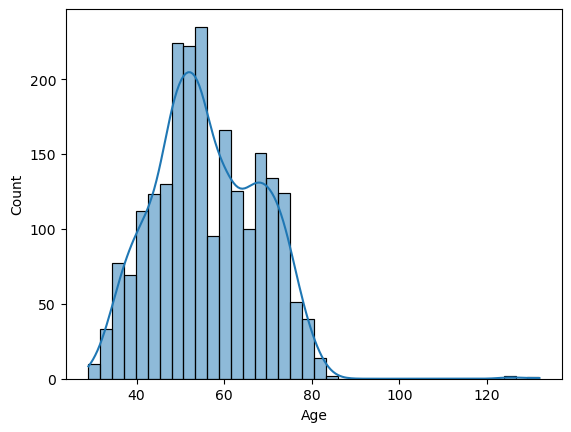

In [32]:
sns.histplot(data=df, x='Age', kde=True)

<Axes: xlabel='Income', ylabel='Count'>

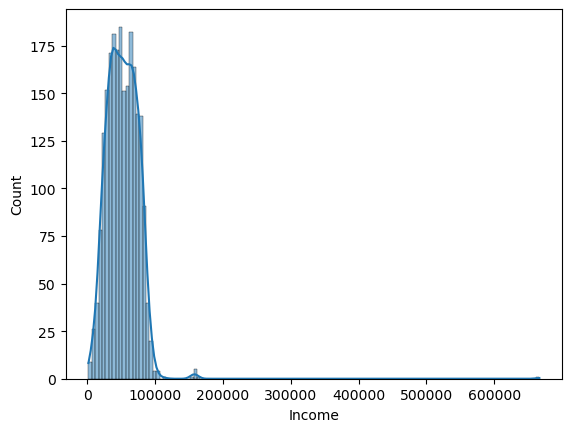

In [33]:
sns.histplot(data=df, x='Income', kde=True)

In [ ]:
#dựa theo các đồ thị trên, ta có thể đặt điều kiện Age< 100 và Income < 200000 để loại bỏ các outliner

In [34]:
condition = (df['Age'] < 100 ) & (df['Income'] < 200000)
df = df[condition]

In [35]:
df.describe()

,Income,Kidhome,Teenhome,Wines,Fruits,Meat,Fish,Sweet,Gold,NumDealsPurchases,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Age,purchase_recency,Spent
count,2236.000000,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,51952.614043,0.444097,0.506708,304.12746,26.275939,166.983453,37.536225,27.080501,43.983005,2.326029,...,5.795617,5.318873,0.072898,0.074687,0.072451,0.064401,0.013417,56.101968,353.773256,605.986583
std,21411.466851,0.538459,0.544609,336.59181,39.724007,225.689645,54.648562,41.299504,52.061568,1.933032,...,3.251129,2.426886,0.260027,0.262944,0.259291,0.245520,0.115077,11.703281,202.181561,601.865156
min,1730.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,0.000000,5.000000
25%,35502.500000,0.000000,0.000000,24.00000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,180.750000,69.000000
50%,51381.500000,0.000000,0.000000,174.00000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,356.000000,396.500000
75%,68275.750000,1.000000,1.000000,504.25000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,529.000000,1045.500000
max,162397.000000,2.000000,2.000000,1493.00000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,85.000000,699.000000,2525.000000


In [ ]:
#cần kiểm tra mối quan hệ tương quan giữa các biến để loại bỏ bớt 1 số biến thừa, tránh bị lỗi đa cộng tuyến (Multicollinearity)

In [36]:
df['Is_parent'] = np.where((df['Kidhome'] > 0) | (df['Teenhome'] > 0), 1,0)

In [37]:
df_numeric_cols= df.select_dtypes(include = 'number')

In [38]:
corr_score = df_numeric_cols.corr()

In [39]:
abs_corr_score = corr_score.abs()

<Axes: >

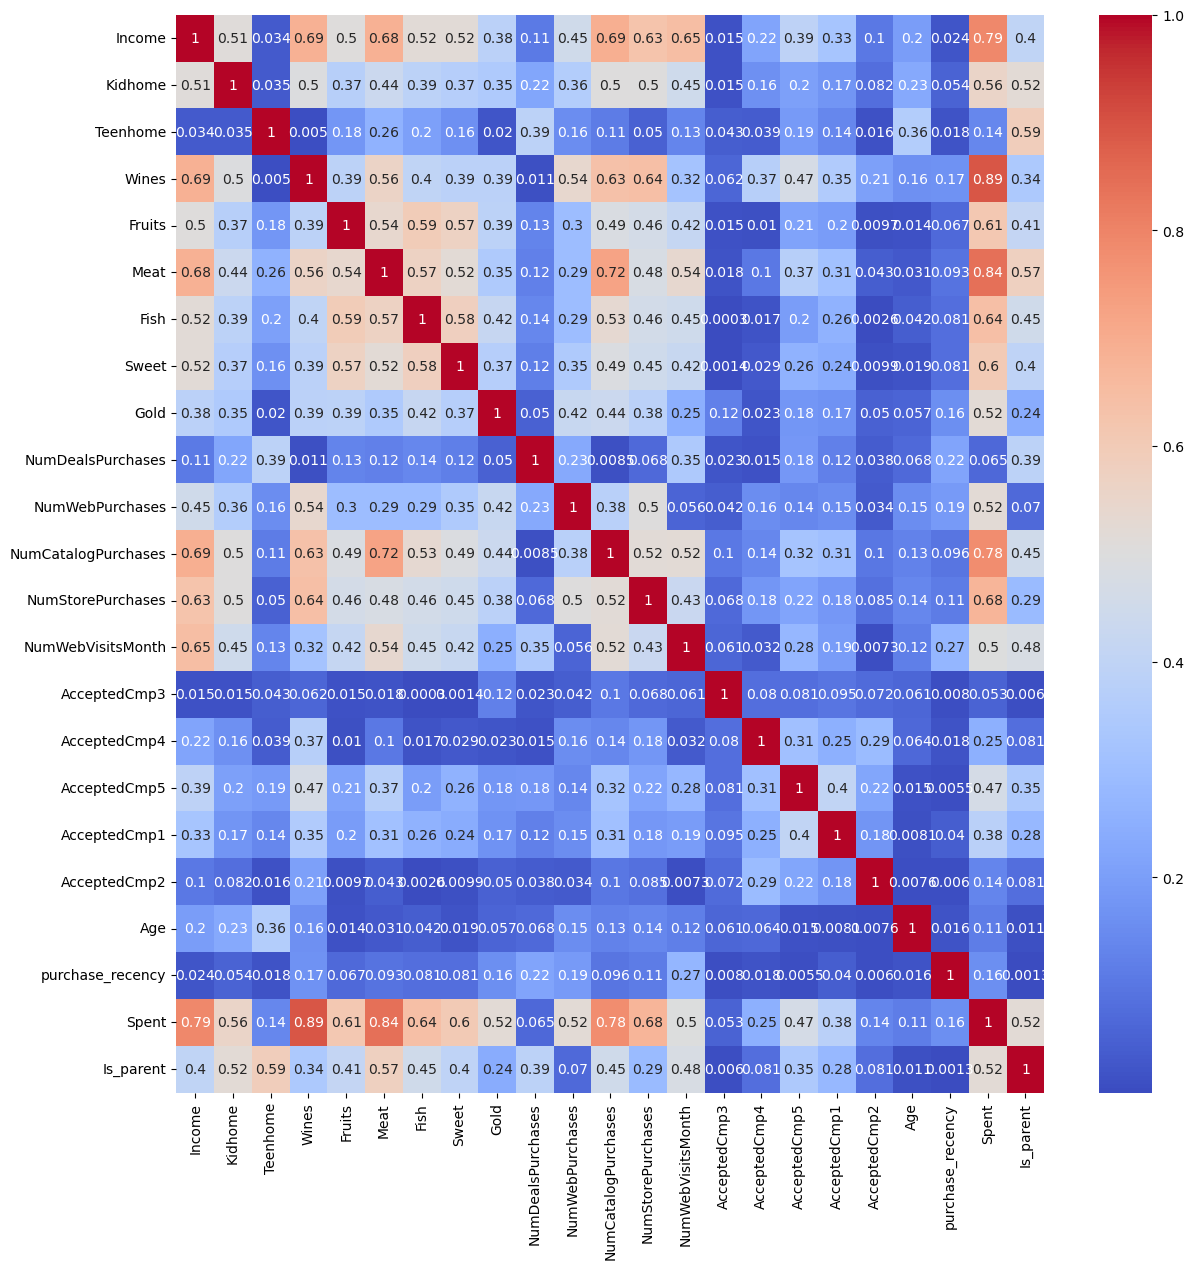

In [40]:
plt.figure(figsize  = (14,14))
sns.heatmap(abs_corr_score, annot = True, cmap = 'coolwarm')

In [41]:
abs_corr_score

,Income,Kidhome,Teenhome,Wines,Fruits,Meat,Fish,Sweet,Gold,NumDealsPurchases,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Age,purchase_recency,Spent,Is_parent
Income,1.000000,0.510441,0.034315,0.686080,0.504911,0.684176,0.518462,0.518126,0.383548,0.107169,...,0.646382,0.015064,0.217659,0.394308,0.325254,0.104062,0.198835,0.023677,0.789375,0.401361
Kidhome,0.510441,1.000000,0.035339,0.496166,0.372442,0.436901,0.387404,0.370486,0.349462,0.221489,...,0.447626,0.014739,0.161686,0.204918,0.172435,0.081760,0.233894,0.054036,0.556719,0.520676
Teenhome,0.034315,0.035339,1.000000,0.005047,0.176117,0.261171,0.204177,0.162527,0.020447,0.388293,...,0.134636,0.042949,0.038680,0.190383,0.140426,0.015715,0.363172,0.017871,0.138197,0.587375
Wines,0.686080,0.496166,0.005047,1.000000,0.388472,0.561886,0.398956,0.385845,0.386234,0.011173,...,0.320287,0.062103,0.373491,0.471949,0.354328,0.206031,0.162809,0.166068,0.891696,0.342780
Fruits,0.504911,0.372442,0.176117,0.388472,1.000000,0.542030,0.594415,0.567030,0.389999,0.131792,...,0.417405,0.014945,0.010363,0.211996,0.195351,0.009717,0.013657,0.067104,0.613122,0.412210
Meat,0.684176,0.436901,0.261171,0.561886,0.542030,1.000000,0.567813,0.523329,0.348727,0.122242,...,0.539183,0.018250,0.102981,0.372173,0.310053,0.043060,0.030729,0.092605,0.842624,0.574356
Fish,0.518462,0.387404,0.204177,0.398956,0.594415,0.567813,1.000000,0.579490,0.422018,0.139263,...,0.445729,0.000302,0.016797,0.198112,0.260866,0.002555,0.042359,0.080636,0.642335,0.450162
Sweet,0.518126,0.370486,0.162527,0.385845,0.567030,0.523329,0.579490,1.000000,0.369084,0.120064,...,0.423215,0.001412,0.028534,0.258797,0.241826,0.009940,0.019379,0.081012,0.602610,0.396881
Gold,0.383548,0.349462,0.020447,0.386234,0.389999,0.348727,0.422018,0.369084,1.000000,0.050192,...,0.249041,0.123670,0.022547,0.176323,0.167090,0.050224,0.057419,0.160189,0.522653,0.241493
NumDealsPurchases,0.107169,0.221489,0.388293,0.011173,0.131792,0.122242,0.139263,0.120064,0.050192,1.000000,...,0.347216,0.023271,0.015452,0.182836,0.123451,0.037776,0.068286,0.218009,0.064831,0.387438


In [42]:
list = abs_corr_score.select_dtypes(include = 'number')
list = list.unstack()
gf = list.reset_index()
gf.columns = ['Biến 1','Biến 2','Hệ số tương quan']
gf = gf[(gf['Hệ số tương quan'] > 0.8) & (gf['Hệ số tương quan'] < 1) ]
gf

,Biến 1,Biến 2,Hệ số tương quan
90,Wines,Spent,0.891696
136,Meat,Spent,0.842624
486,Spent,Wines,0.891696
488,Spent,Meat,0.842624


In [ ]:
#từ bảng trên suy ra ta không cần loại bỏ biến nào thì mục tiêu ta đang hướng tới là 
#dự đoán tổng chi (Spent) dựa trên ảnh hưởng của các biến còn lại

In [ ]:
#encode các biến có định dạng chữ sang dạng số

In [43]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweet', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Age', 'purchase_recency', 'Spent',
       'Is_parent'],
      dtype='object')

In [44]:
object_col_2 = df.select_dtypes(include = 'object')
object_col_2.columns

Index(['Education', 'Marital_Status'], dtype='object')

In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

In [46]:
LE = LabelEncoder()
for i in object_col_2:
    df[i] = df[[i]].apply(LE.fit_transform)

In [47]:
df.describe()

,Education,Marital_Status,Income,Kidhome,Teenhome,Wines,Fruits,Meat,Fish,Sweet,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Age,purchase_recency,Spent,Is_parent
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,2236.000000,...,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,0.610465,0.644902,51952.614043,0.444097,0.506708,304.12746,26.275939,166.983453,37.536225,27.080501,...,5.318873,0.072898,0.074687,0.072451,0.064401,0.013417,56.101968,353.773256,605.986583,0.715116
std,0.682709,0.478650,21411.466851,0.538459,0.544609,336.59181,39.724007,225.689645,54.648562,41.299504,...,2.426886,0.260027,0.262944,0.259291,0.245520,0.115077,11.703281,202.181561,601.865156,0.451460
min,0.000000,0.000000,1730.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,0.000000,5.000000,0.000000
25%,0.000000,0.000000,35502.500000,0.000000,0.000000,24.00000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,180.750000,69.000000,0.000000
50%,0.000000,1.000000,51381.500000,0.000000,0.000000,174.00000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,356.000000,396.500000,1.000000
75%,1.000000,1.000000,68275.750000,1.000000,1.000000,504.25000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,529.000000,1045.500000,1.000000
max,2.000000,1.000000,162397.000000,2.000000,2.000000,1493.00000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,85.000000,699.000000,2525.000000,1.000000


In [ ]:
#tất cả biến đã chuyển thành dạng số, bây giờ ta sẽ scale các biến để tránh 1 số biến có giá trị lớn ảnh hưởng tới chất lượng chạy mô hình

In [ ]:
#Tôi muốn kiểm tra các biến demographics có ảnh hưởng như nào tới spent,
#nên ta tạm thời loại bỏ 1 số biến liên quan tới việc chấp nhận khuyến mãi AcceptedCmp1,2,3,4,5 và số lần ử dụng các kênh mua hàng  ra khỏi mô hình để kiểm tra 

In [48]:
df_demo = df.copy()

In [49]:
df_demo.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweet', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Age', 'purchase_recency', 'Spent',
       'Is_parent'],
      dtype='object')

In [50]:
df_demo.drop(columns = [ 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweet', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2'], inplace = True)

In [51]:
df_demo.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Age',
       'purchase_recency', 'Spent', 'Is_parent'],
      dtype='object')

In [52]:
scaler = StandardScaler()
scaler.fit(df_demo)
scale_data = pd.DataFrame(scaler.transform(df_demo), columns = df_demo.columns)


In [53]:
scale_data.describe()

,Education,Marital_Status,Income,Kidhome,Teenhome,Age,purchase_recency,Spent,Is_parent
count,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,6.514368e-17,9.692108e-17,-7.785464e-17,3.416071e-17,1.906644e-17,6.514368e-17,2.542192e-17,4.766610e-18,-1.461761e-16
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-8.943804e-01,-1.347635e+00,-2.346119e+00,-8.249389e-01,-9.306153e-01,-2.316276e+00,-1.750171e+00,-9.987636e-01,-1.584362e+00
25%,-8.943804e-01,-1.347635e+00,-7.684571e-01,-8.249389e-01,-9.306153e-01,-6.924366e-01,-8.559730e-01,-8.924037e-01,-1.584362e+00
50%,-8.943804e-01,7.420405e-01,-2.667925e-02,-8.249389e-01,-9.306153e-01,-9.417994e-02,1.101605e-02,-3.481402e-01,6.311687e-01
75%,5.706999e-01,7.420405e-01,7.625254e-01,1.032627e+00,9.059742e-01,8.459377e-01,8.668740e-01,7.304157e-01,6.311687e-01
max,2.035780e+00,7.420405e-01,5.159343e+00,2.890194e+00,2.742564e+00,2.469777e+00,1.707891e+00,3.189157e+00,6.311687e-01


In [54]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(scale_data) # X_scaled là dữ liệu đã chuẩn hóa ở bước trước

# 2. Tạo DataFrame mới để vẽ đồ thị
df_visual = pd.DataFrame(df_pca, columns=['Component 1', 'Component 2'])


Elbow Method to determine the number of clusters to be formed:


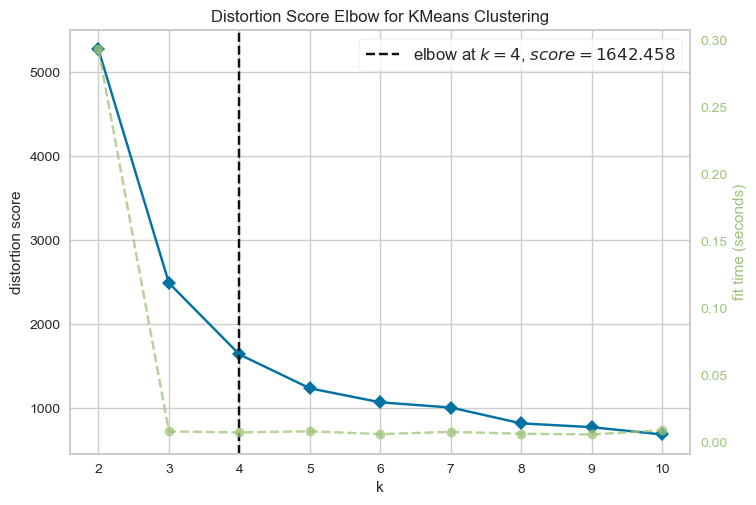

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [55]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(df_visual)
Elbow_M.show()

In [56]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans_4.fit_predict(df_visual)

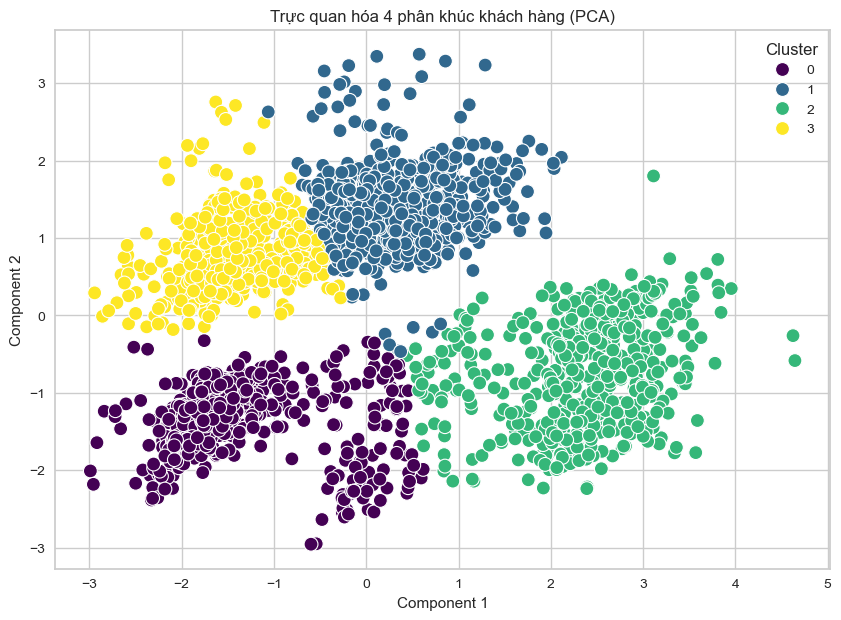

In [57]:
df_visual['Cluster'] = labels

# 3. Vẽ biểu đồ scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_visual, x='Component 1', y='Component 2', hue='Cluster', palette='viridis', s=100)
plt.title('Trực quan hóa 4 phân khúc khách hàng (PCA)')
plt.show()

In [62]:
df['Cluster'] = labels

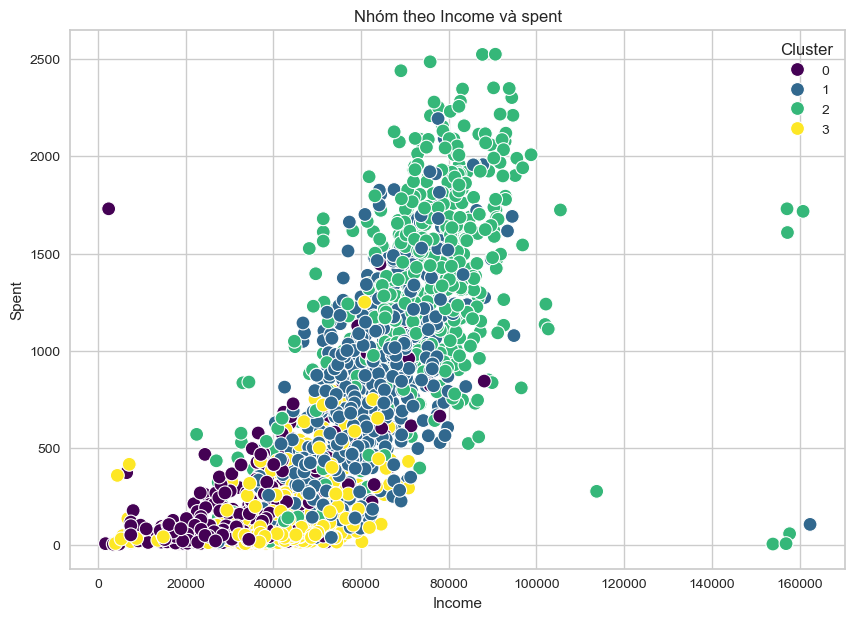

In [63]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Income', y='Spent', hue='Cluster', palette='viridis', s=100)
plt.title('Nhóm theo Income và spent')
plt.show()

In [ ]:
#ta có thể thấy có sự khác biệt khá rõ giữa nhóm 1,2 và nhóm 0,3, 
#với những người có thu nhập > 60000 có xu hướng tiêu dùng cao gần gần đôi hoặc nhiều lần so với 2 nhóm còn lại, 
#mức chi tiêu của nhóm có thu nhập thấp hơn thường 500$

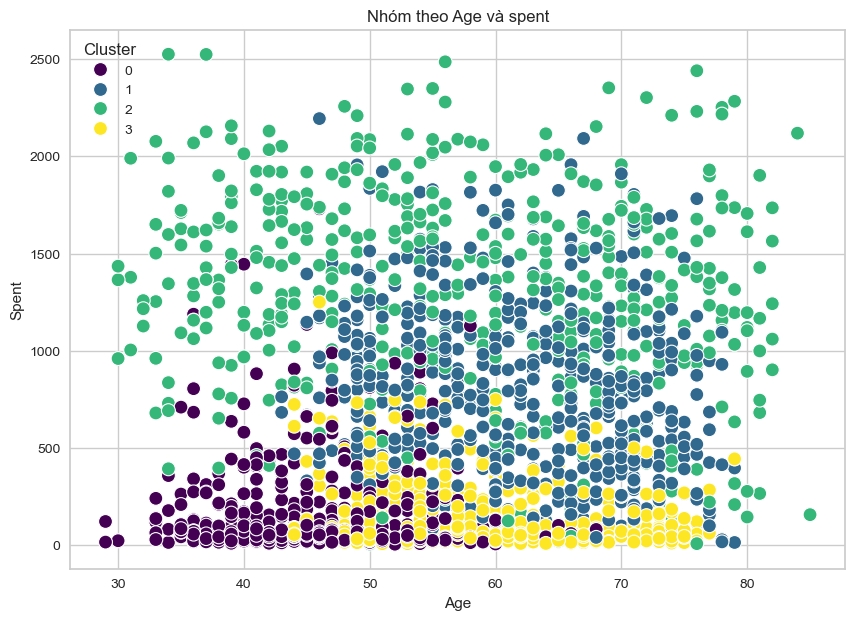

In [64]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Age', y='Spent', hue='Cluster', palette='viridis', s=100)
plt.title('Nhóm theo Age và spent')
plt.show()

In [ ]:
#Nhìn biểu đồ có thể thấy biến tuổi không có nhiều tác động tới mức tiêu dùng 

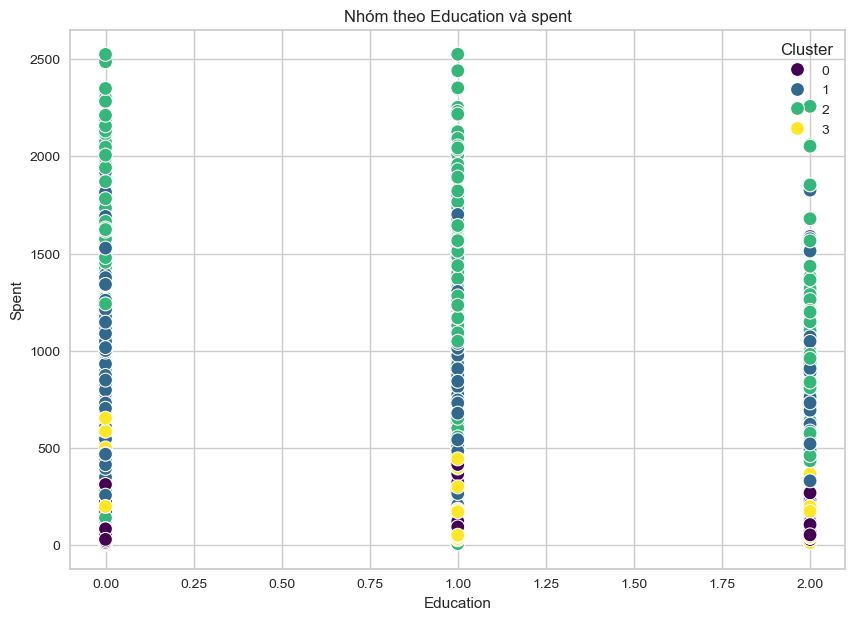

In [65]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Education', y='Spent', hue='Cluster', palette='viridis', s=100)
plt.title('Nhóm theo Education và spent')
plt.show()

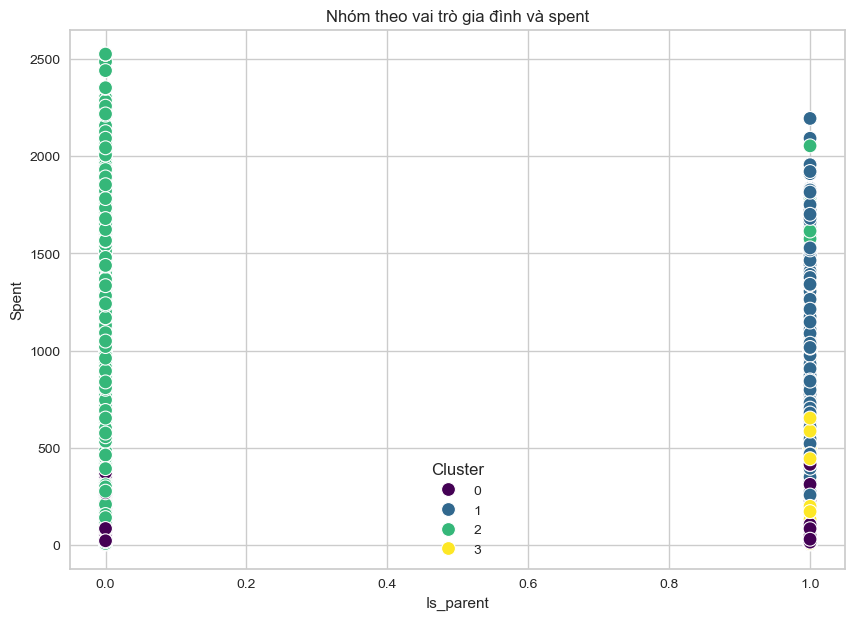

In [66]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_demo, x='Is_parent', y='Spent', hue='Cluster', palette='viridis', s=100)
plt.title('Nhóm theo vai trò gia đình và spent')
plt.show()

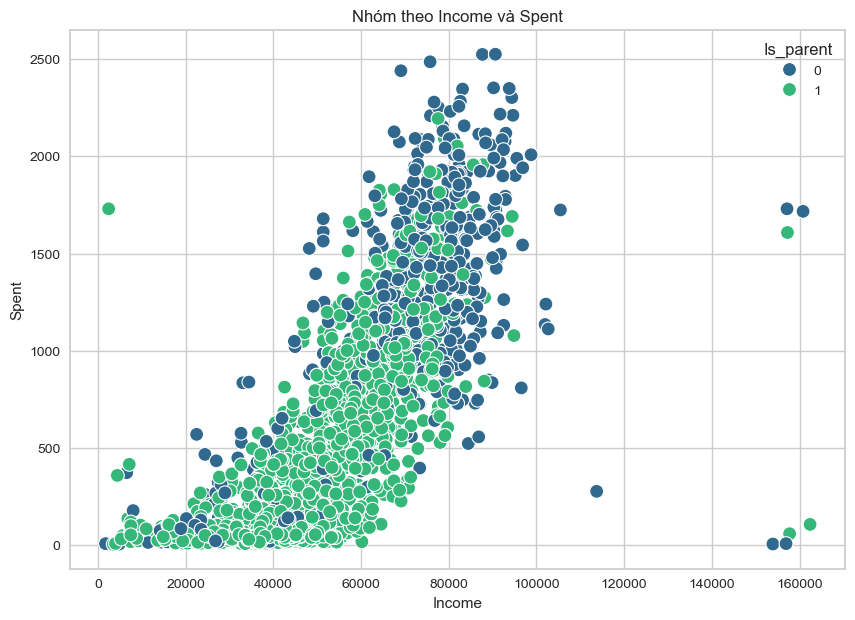

In [69]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_demo, x='Income', y='Spent', hue='Is_parent', palette='viridis', s=100)
plt.title('Nhóm theo Income và Spent')
plt.show()

In [ ]:
#người không có con đa phân có thu nhập cao và chi tiêu cao hơn so với những nhóm người khác

In [70]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweet', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Age', 'purchase_recency', 'Spent',
       'Is_parent', 'Cluster'],
      dtype='object')

In [72]:
df['Total_kids'] = df['Kidhome'] + df['Teenhome']

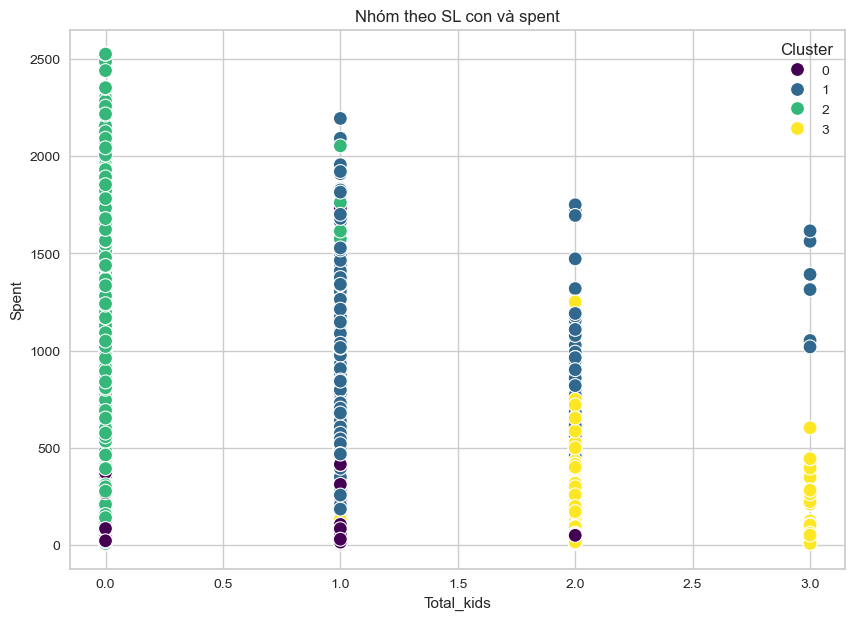

In [73]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Total_kids', y='Spent', hue='Cluster', palette='viridis', s=100)
plt.title('Nhóm theo SL con và spent')
plt.show()

In [ ]:
#nhóm 2 là nhóm không có con và có mức chi tiêu và thu nhập cao
#nhóm 0 là nhóm chưa có con hoặc chỉ có 1 con, thu nhập và chi tiêu thấp
#nhóm 1 là nhóm đã là ba mẹ có từ 1-3 con, mức thu nhập trung bình và mức chi tiêu trung bình
#nhóm 3 là nhóm có ít nhất 2 đứa con, có thu nhập và mức chi thấp. 

# => Nhóm cần tập trung là nhóm 2 và nhóm 0

<Axes: xlabel='Cluster', ylabel='Spent'>

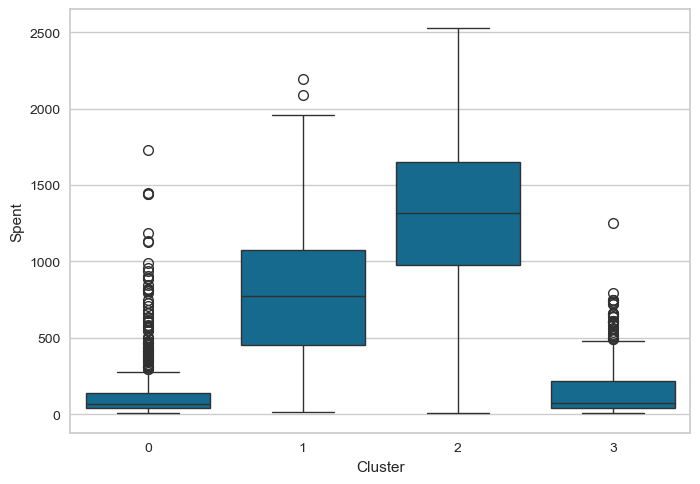

In [77]:
sns.boxplot(x='Cluster', y='Spent', data=df)

In [78]:
df["Total_Promos"] = df["AcceptedCmp1"]+ df["AcceptedCmp2"]+ df["AcceptedCmp3"]+ df["AcceptedCmp4"]+ df["AcceptedCmp5"]

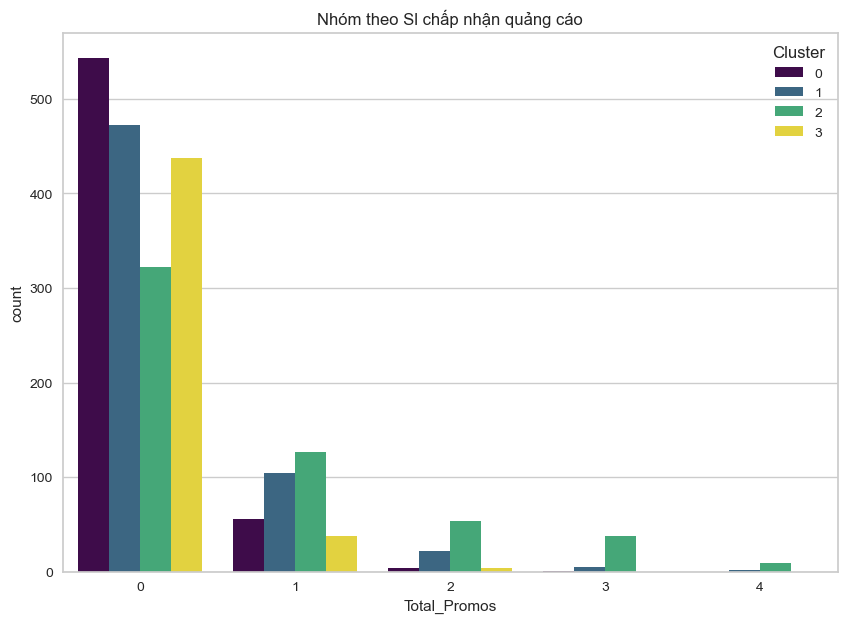

In [108]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Total_Promos', hue = 'Cluster', palette='viridis')
plt.title('Nhóm theo Sl chấp nhận quảng cáo')
plt.show()

In [88]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweet', 'Gold', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Age', 'purchase_recency', 'Spent',
       'Is_parent', 'Cluster', 'Total_kids', 'Total_Promos'],
      dtype='object')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9184\1712353744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cluster', y= i,  palette='viridis')


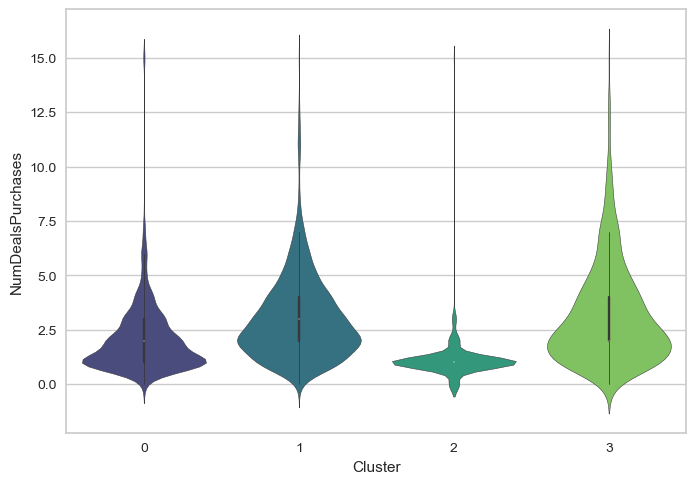

<Figure size 1000x700 with 0 Axes>

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9184\1712353744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cluster', y= i,  palette='viridis')


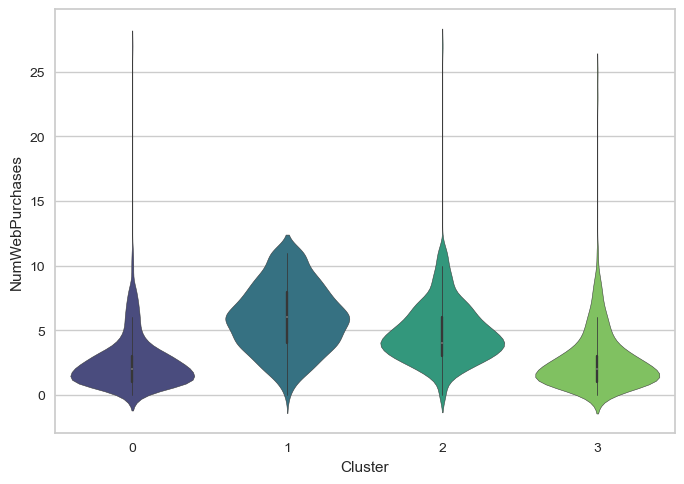

<Figure size 1000x700 with 0 Axes>

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9184\1712353744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cluster', y= i,  palette='viridis')


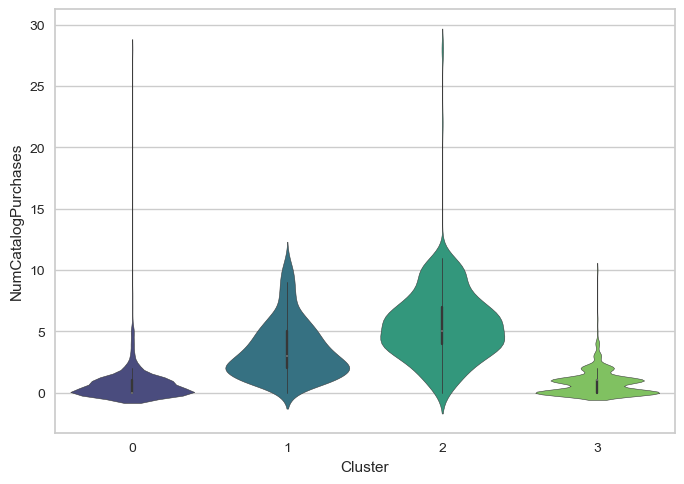

<Figure size 1000x700 with 0 Axes>

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9184\1712353744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cluster', y= i,  palette='viridis')


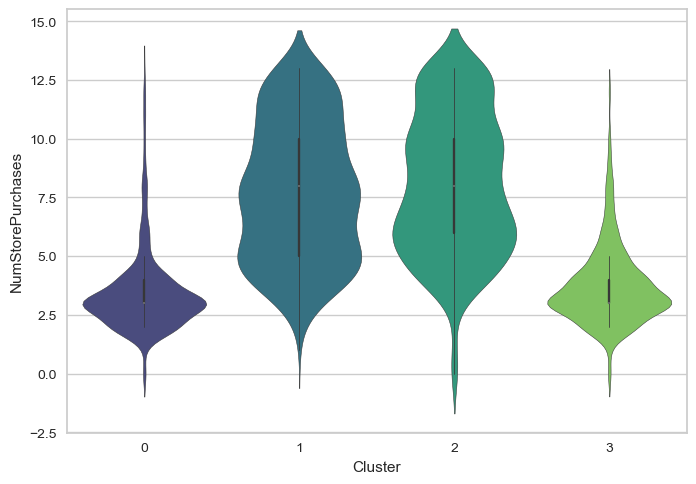

<Figure size 1000x700 with 0 Axes>

In [105]:

for i in ['NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']:
    sns.violinplot(data=df, x='Cluster', y= i,  palette='viridis')
    plt.figure(figsize=(10, 7))
    plt.show()


In [ ]:
#Nhìn chung nhóm chi tiêu ít 0,3 không hay mua ở cửa hàng hay catolo hay ..., tuy nhiên lại bị hấp dẫn bởi Deals,
# => áp dụng tốt deal cho 2 nhóm này